In [1]:
import anndata as ad
import scanpy as sc

## Load data

In [74]:
# load raw data
adata = ad.read_csv("../Day-Investigation/Data/GSE151334_counts.mouse.tsv", delimiter="\t")

# transpose from R convention (cells as columns) to Python convention (cells as rows)
adata = adata.transpose()
adata

c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)


AnnData object with n_obs × n_vars = 2183 × 55293

## QC

In [75]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("Mt")

In [76]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, log1p=True)

c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\scanpy\preprocessing\_qc.py:428: RuntimeWarning: invalid value encountered in divide
  return values / sums[:, None]


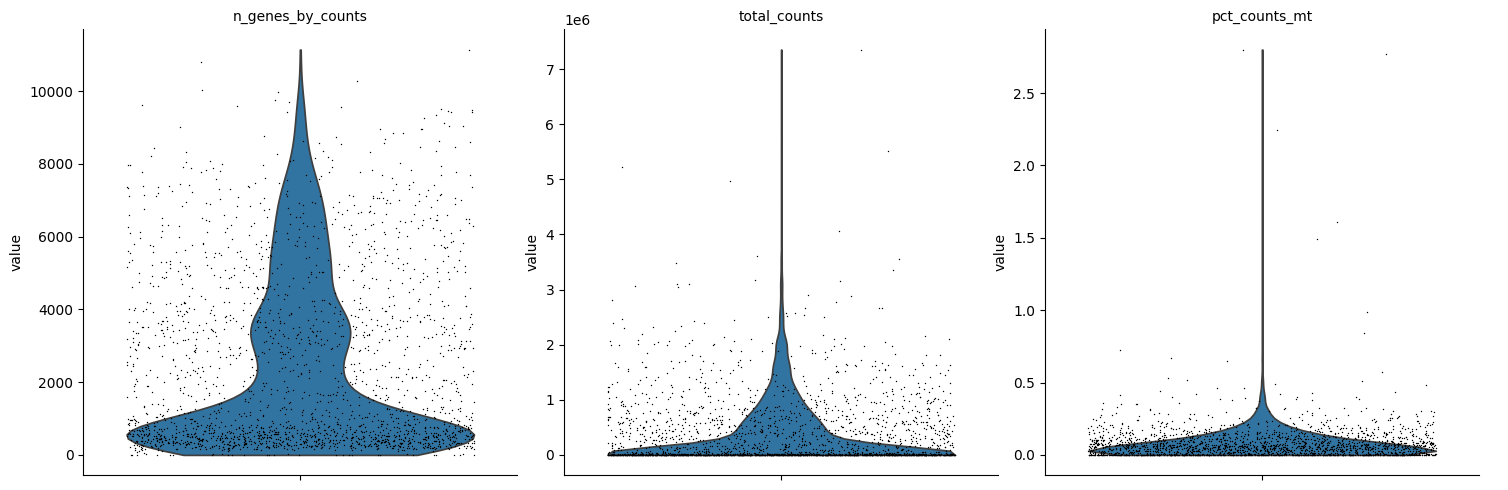

In [77]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

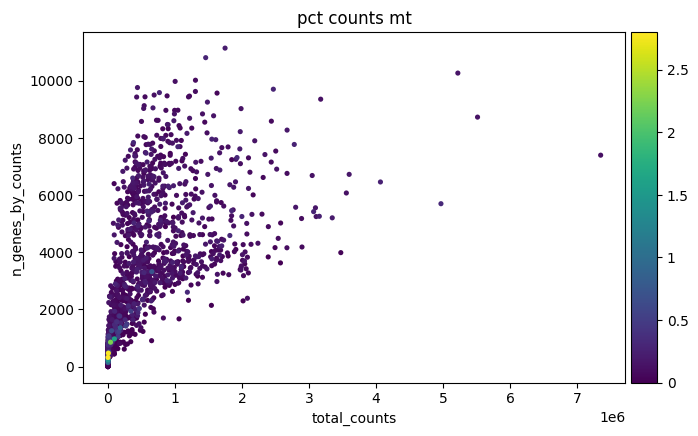

In [78]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

## Filtering & Normalization

In [79]:
# perform basic filtering for now
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

In [81]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

In [82]:
# Normalizing to median total counts
sc.pp.normalize_total(adata)

# Logarithmize the data
sc.pp.log1p(adata)

In [83]:
adata

AnnData object with n_obs × n_vars = 2149 × 37130
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p'
    layers: 'counts'

In [84]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

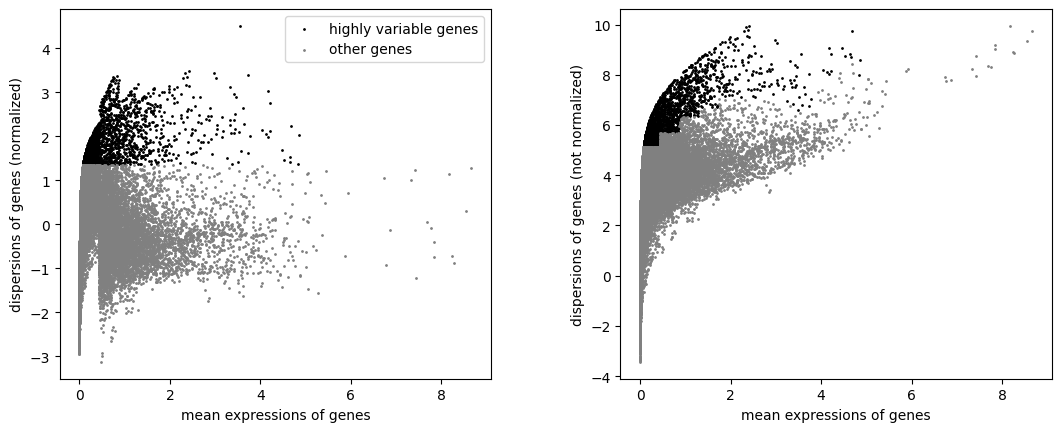

In [85]:
sc.pl.highly_variable_genes(adata)

## Dimensionality Reduction: PCA

In [86]:
sc.tl.pca(adata)

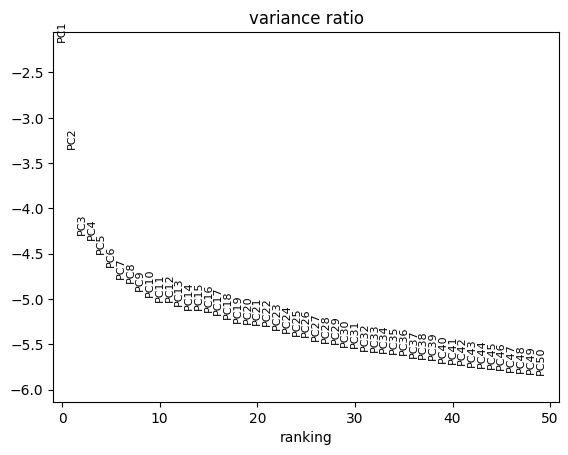

In [87]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

## Nearest Neighbour graph and UMAP on PCA space

In [90]:
sc.pp.neighbors(adata, n_pcs=15)

In [93]:
sc.tl.umap(adata, n_components=15)

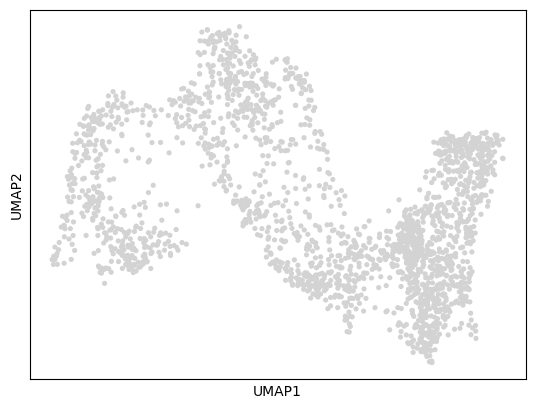

In [95]:
sc.pl.umap(adata)

In [96]:
sc.tl.draw_graph(adata)

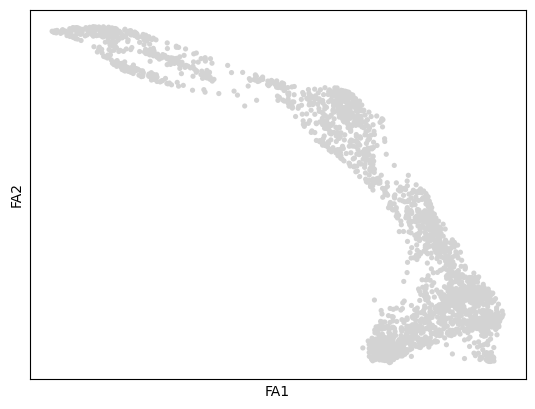

In [97]:
sc.pl.draw_graph(adata)

## Clustering

In [99]:
sc.tl.leiden(adata)

C:\Users\willi\AppData\Local\Temp\ipykernel_5736\3467744858.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


## PAGA trajectory inference

In [101]:
sc.tl.paga(adata, groups="leiden")

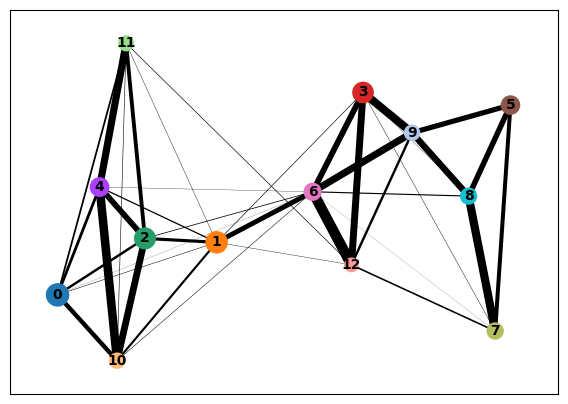

In [102]:
sc.pl.paga(adata, color=["leiden"])

### PAGA informed graph

In [103]:
sc.tl.draw_graph(adata, init_pos="paga")

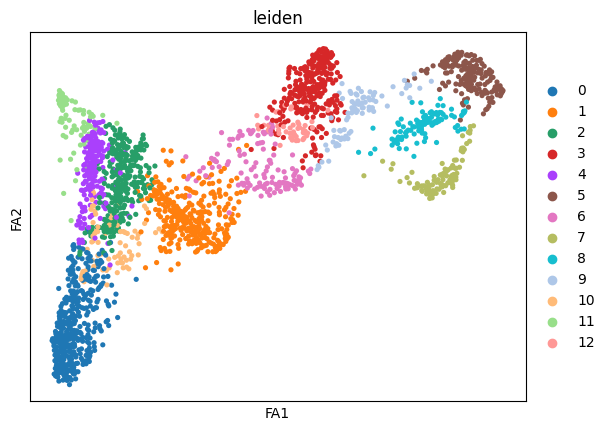

In [104]:
sc.pl.draw_graph(adata, color="leiden")

## Pseudotime: use root node

In [115]:
adata.uns["iroot"] = adata.obs_names.get_loc("mESC_d0_p2_A7_S7")

In [116]:
sc.tl.dpt(adata)

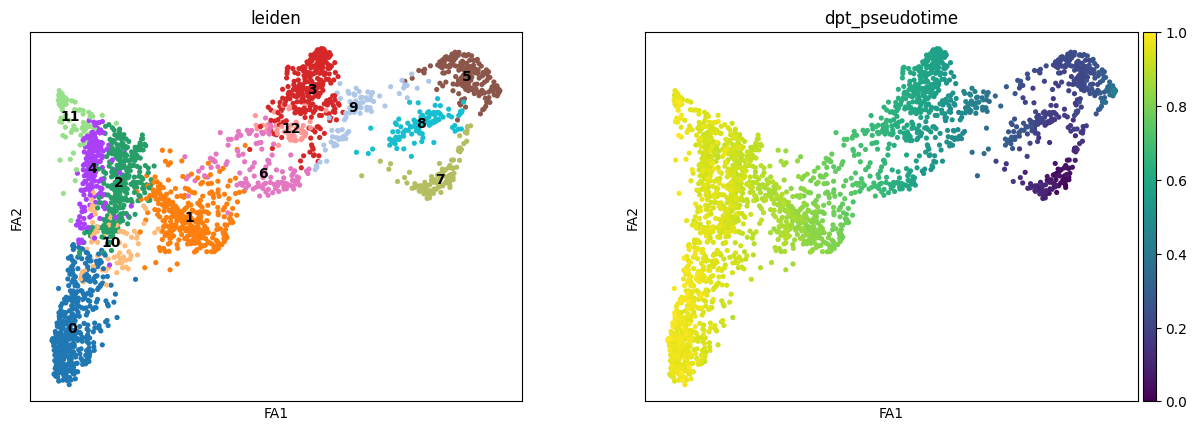

In [121]:
sc.pl.draw_graph(adata, color=["leiden", "dpt_pseudotime"], legend_loc="on data")

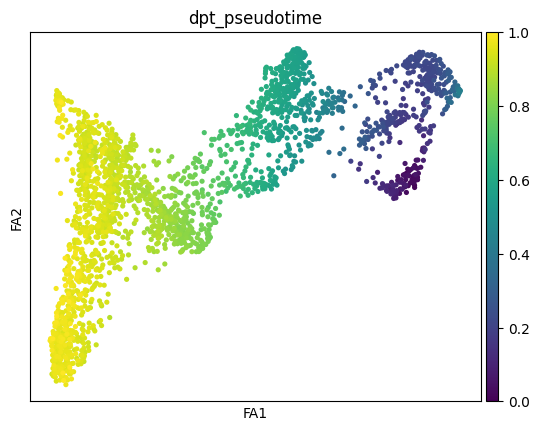

In [140]:
sc.pl.draw_graph(adata, color=["dpt_pseudotime"])

In [139]:
adata.obsp['connectivities']

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 45160 stored elements and shape (2149, 2149)>

In [137]:
import matplotlib.pyplot as plt

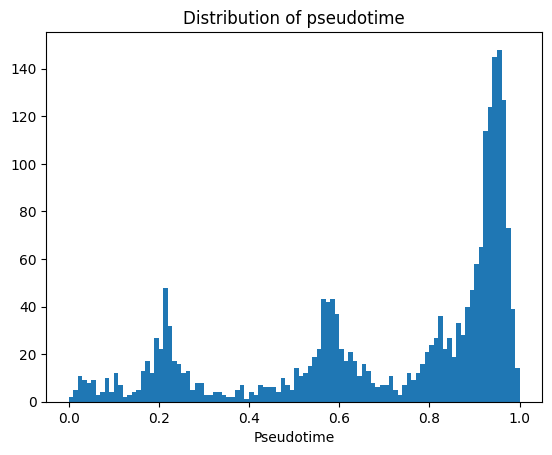

In [124]:
plt.hist(adata.obs['dpt_pseudotime'].to_numpy(dtype=float), bins=100);
plt.xlabel("Pseudotime")
plt.title("Distribution of pseudotime")
plt.show()

# Notes

- distribution of pseudotimes different to that of R results: still peaked but less extreme, and many cells with values close to 1, where previously there were none
- still unclear about many steps of the process
- should days / plates be used as a batch?

How should pseudotime be used?

- potentially multiple branches to trajectory, so may not make sense to just use pseudotime difference as way to group cells
    - could use connectivities computed to obtains groups?